# Mini Project: Zion Central Command — A Full-Stack Student Analytics System

## 🟢 THE MATRIX ARC — Capstone: *Zion Comes Online*

Neo's training inside the Construct is over. Everything learned across ten separate simulations — variables, control flow, data structures, functions, files, classes, and data visualization — now has to run together, at once, in the real system: Zion's Central Command. This mini-project pulls every concept from Experiments 1–10 into a single working pipeline: read a raw, imperfect dataset of student records, validate and model it with real objects, compute analytics, and render a final command-center dashboard.

<div class="alert alert-block alert-info">
<b>🎯 Aim:</b> To design and build an end-to-end Python program that combines OOP, file handling, custom exception handling, functions, string processing, dictionaries/sets, and data visualization into one cohesive student-analytics system.
</div>

## 🧩 Python Concepts Combined

- Classes & objects (`Student`)
- File I/O (`csv` module, reading from `../datasets/student_records.csv`)
- Custom exceptions (`MissingFieldError`, `InvalidScoreError`)
- Functions, loops, and conditionals (grading logic, aggregation)
- String methods (case-insensitive name search)
- Dictionaries and sets (subject averages, grade distribution, unique programmes)
- `sorted()` with a custom key (ranking top performers)
- pandas, NumPy-backed aggregation, and a Seaborn/Matplotlib dashboard

### 📋 Problem Statement
> Build a program that reads student academic records from a CSV file that may contain malformed rows, models each valid record as a `Student` object, computes each student's percentage/CGPA/grade/result, gracefully reports (rather than crashes on) bad records, and produces a final analytics dashboard summarizing class performance.

### ⚠️ Step 1 — Custom Exceptions

<div class="alert alert-block alert-warning">
<b>Why custom exceptions:</b> The raw dataset has two deliberately broken rows. Rather than let a `ValueError` or an `IndexError` crash the whole load, these two exception types let the loader report exactly what went wrong, per row, and keep going.
</div>

In [1]:
class MissingFieldError(Exception):
    """Raised when a CSV row doesn't have the expected number of fields."""
    pass


class InvalidScoreError(Exception):
    """Raised when a subject score can't be parsed as a number."""
    pass

### 🏗️ Step 2 — The `Student` Class

<div class="alert alert-block alert-info">
<b>OOP design:</b> Each student becomes one object carrying its own marks, with methods to derive percentage, CGPA, letter grade, and pass/fail — the same grading ladder used back in Experiment 3, now reused as a method instead of a standalone function.
</div>

In [2]:
class Student:
    """Models a single student's academic record and derived statistics."""

    def __init__(self, name, sap_id, programme, city, marks):
        self.name = name
        self.sap_id = sap_id
        self.programme = programme
        self.city = city
        self.marks = marks  # dict, e.g. {"phy": 88.0, "chem": 76.0, "maths": 91.0}

    def percentage(self):
        return sum(self.marks.values()) / len(self.marks)

    def cgpa(self):
        return round(self.percentage() / 10, 2)

    def grade(self):
        cgpa = self.cgpa()
        if cgpa <= 3.4:
            return "F"
        if cgpa <= 5.0:
            return "C+"
        if cgpa <= 6.0:
            return "B"
        if cgpa <= 7.0:
            return "B+"
        if cgpa <= 8.0:
            return "A"
        if cgpa <= 9.0:
            return "A+"
        return "O (Outstanding)"

    def result(self):
        return "Pass" if all(score > 40 for score in self.marks.values()) else "Fail"

    def __repr__(self):
        return f"Student({self.name}, {self.programme}, {self.percentage():.1f}%)"

### 📂 Step 3 — Loading & Validating the Dataset

### 📋 Problem Statement
> Read `datasets/student_records.csv`, converting each well-formed row into a `Student` object while safely rejecting malformed rows with a clear reason.

<div class="alert alert-block alert-success">
<b>Sample Input & Output:</b> Input: 18 raw data rows (16 valid, 2 malformed). Expected output: 16 `Student` objects loaded, and 2 rejection messages naming the exact row and reason.
</div>

In [3]:
import csv


def load_students(file_path):
    """Reads the raw CSV, returning (valid_students, rejected_reasons).
    Bad rows are reported, not allowed to crash the whole load."""
    students = []
    rejected = []
    with open(file_path, "r", encoding="utf-8") as file:
        reader = csv.reader(file)
        header = next(reader)
        expected_fields = len(header)

        for row_number, row in enumerate(reader, start=2):
            try:
                if len(row) != expected_fields:
                    raise MissingFieldError(
                        f"Row {row_number}: expected {expected_fields} fields, got {len(row)}"
                    )
                name, sap_id, programme, city, phy, chem, maths = row
                try:
                    marks = {"phy": float(phy), "chem": float(chem), "maths": float(maths)}
                except ValueError as error:
                    raise InvalidScoreError(f"Row {row_number}: non-numeric score(s) -> {error}") from error

                students.append(Student(name, sap_id, programme, city, marks))

            except (MissingFieldError, InvalidScoreError) as error:
                rejected.append(str(error))

    return students, rejected


students, rejected = load_students("../datasets/student_records.csv")

print(f"Loaded {len(students)} valid student record(s).")
print(f"Rejected {len(rejected)} malformed record(s):")
for reason in rejected:
    print("  -", reason)

Loaded 16 valid student record(s).
Rejected 2 malformed record(s):
  - Row 18: expected 7 fields, got 6
  - Row 19: non-numeric score(s) -> could not convert string to float: 'abc'


### 📊 Step 4 — Class Analytics

<div class="alert alert-block alert-info">
<b>Concepts combined here:</b> `sorted()` with a `lambda` key for ranking, dictionaries for subject averages and grade counts, a `set` for unique programmes, and a case-insensitive string search over names — five different data-structure techniques from across the course, used together.
</div>

In [4]:
def subject_averages(student_list):
    subjects = student_list[0].marks.keys()
    return {
        subject: round(sum(s.marks[subject] for s in student_list) / len(student_list), 2)
        for subject in subjects
    }


def top_performers(student_list, n=3):
    return sorted(student_list, key=lambda s: s.percentage(), reverse=True)[:n]


def grade_distribution(student_list):
    distribution = {}
    for s in student_list:
        g = s.grade()
        distribution[g] = distribution.get(g, 0) + 1
    return distribution


def unique_programmes(student_list):
    return {s.programme for s in student_list}


def search_students(student_list, keyword):
    """Case-insensitive substring search over student names."""
    keyword = keyword.lower()
    return [s for s in student_list if keyword in s.name.lower()]


print("Subject-wise class averages:", subject_averages(students))
print()

print("Top 3 performers:")
for s in top_performers(students, 3):
    print(f"  {s.name} ({s.programme}) -> {s.percentage():.1f}%  Grade: {s.grade()}  Result: {s.result()}")
print()

print("Grade distribution:", grade_distribution(students))
print("Programmes represented:", unique_programmes(students))
print()

print("Name search demo, keyword='an':", [s.name for s in search_students(students, "an")])

Subject-wise class averages: {'phy': 70.19, 'chem': 70.0, 'maths': 71.69}

Top 3 performers:
  Yash Chauhan (AI & ML) -> 95.0%  Grade: O (Outstanding)  Result: Pass
  Aditya Rao (AI & ML) -> 92.0%  Grade: O (Outstanding)  Result: Pass
  Omkar Joshi (AI & ML) -> 91.7%  Grade: O (Outstanding)  Result: Pass

Grade distribution: {'A+': 3, 'C+': 3, 'A': 3, 'O (Outstanding)': 3, 'B': 3, 'B+': 1}
Programmes represented: {'Cybersecurity', 'Data Science', 'AI & ML'}

Name search demo, keyword='an': ['Vivek Rana', 'Karan Mehta', 'Sanya Gill', 'Rohan Das', 'Tanya Bhatt', 'Yash Chauhan']


### 📈 Step 5 — The Dashboard

<div class="alert alert-block alert-success">
<b>What this shows:</b> Four linked views of the same underlying data: who's leading, how grades are distributed, the overall shape of the class's performance, and how programmes compare — the same Seaborn/Matplotlib techniques from Experiment 10, now applied to data that was validated and modeled by the rest of this project.
</div>

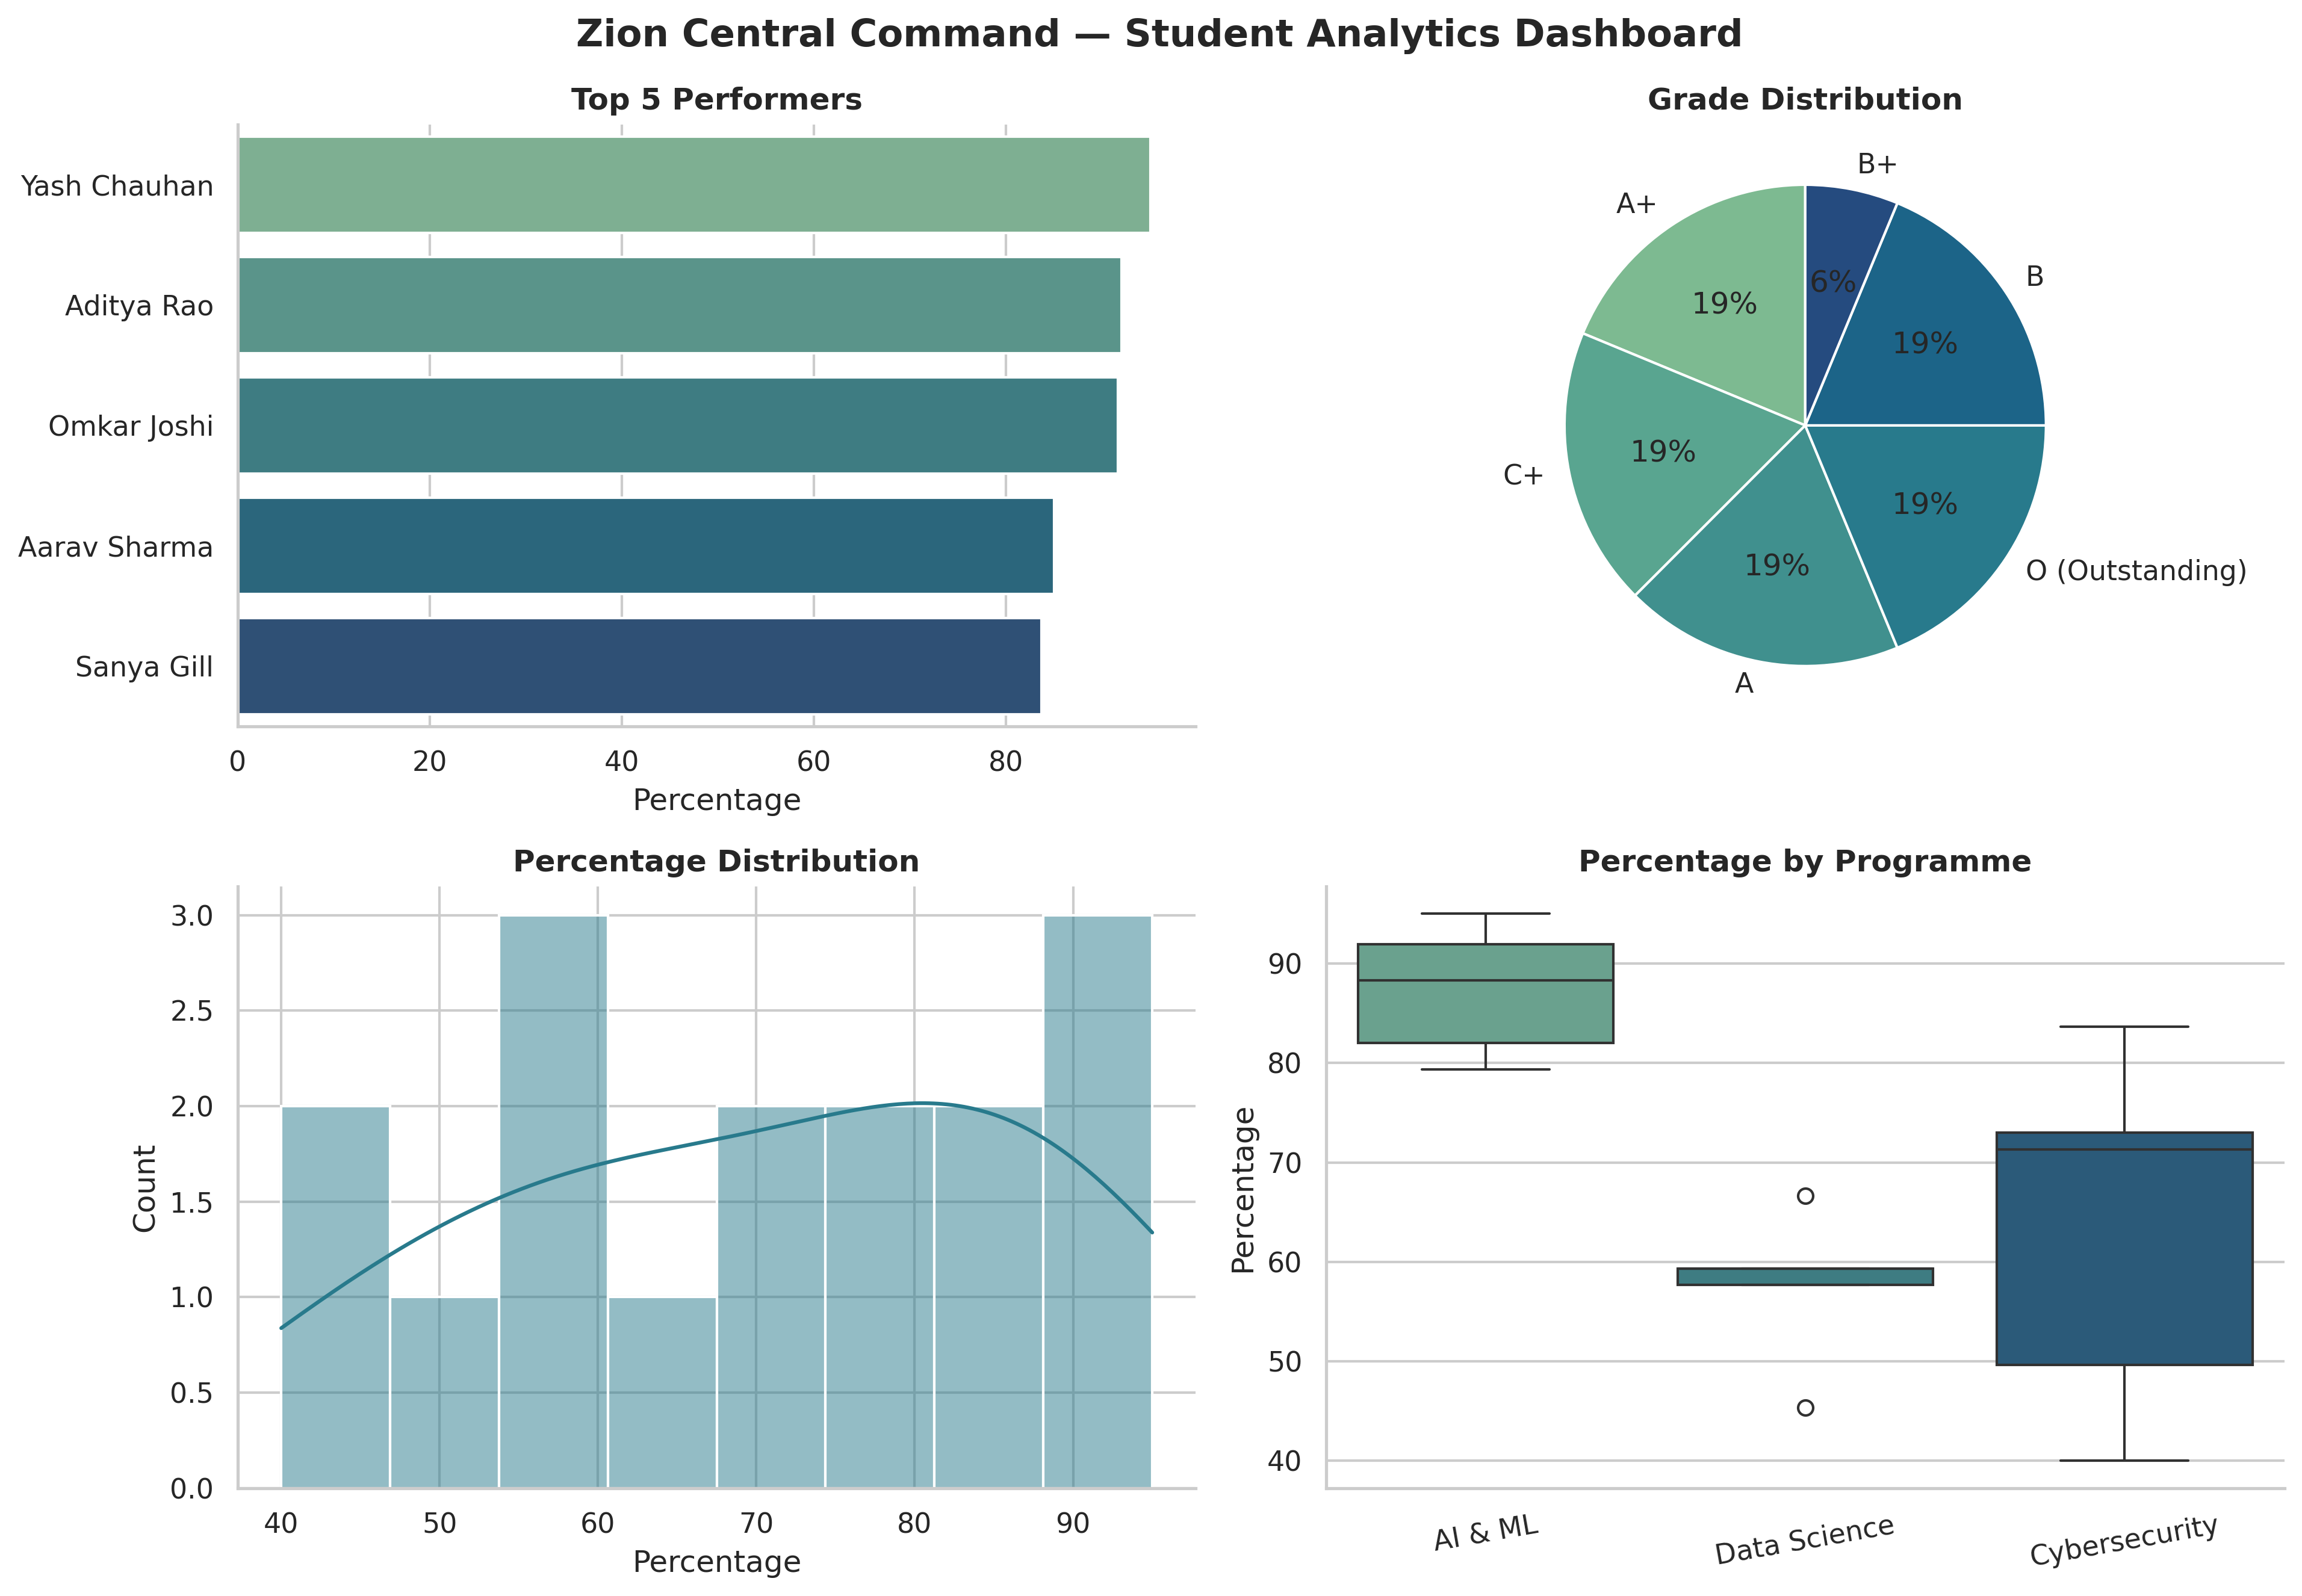

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
palette = sns.color_palette("crest", 6)

records = [{
    "name": s.name,
    "programme": s.programme,
    "percentage": s.percentage(),
    "grade": s.grade(),
} for s in students]
df = pd.DataFrame(records)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=300)
fig.suptitle("Zion Central Command \u2014 Student Analytics Dashboard", fontsize=15, fontweight="bold")

top5 = df.sort_values("percentage", ascending=False).head(5)
sns.barplot(data=top5, x="percentage", y="name", hue="name", palette="crest",
            legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Top 5 Performers", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Percentage"); axes[0, 0].set_ylabel("")

grade_counts = df["grade"].value_counts()
axes[0, 1].pie(grade_counts.values, labels=grade_counts.index, autopct="%1.0f%%",
               startangle=90, colors=sns.color_palette("crest", len(grade_counts)))
axes[0, 1].set_title("Grade Distribution", fontsize=12, fontweight="bold")

sns.histplot(df["percentage"], bins=8, kde=True, color=palette[3], ax=axes[1, 0])
axes[1, 0].set_title("Percentage Distribution", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Percentage"); axes[1, 0].set_ylabel("Count")

sns.boxplot(data=df, x="programme", y="percentage", hue="programme", palette="crest",
            legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Percentage by Programme", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel(""); axes[1, 1].set_ylabel("Percentage")
axes[1, 1].tick_params(axis="x", rotation=10)

sns.despine()
plt.tight_layout()
plt.savefig("../images/mini_project_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

## 📝 Conclusion

<div class="alert alert-block alert-success">
<b>📝 Conclusion:</b> This mini-project combined every major concept from the ten experiments — classes, file handling, custom exceptions, functions, loops, string search, dictionaries/sets, and a pandas/Seaborn dashboard — into a single working pipeline. The dataset itself was intentionally imperfect, so the exception-handling layer isn't decorative: it's what let the rest of the system run safely on real, messy input, which is exactly what happens outside a lab exercise.
</div>